# Module 2, Part B — Titanic: Classification, Tuning & Regression

Continues directly from `01_eda.ipynb`: reads the same `titanic.csv` that
notebook wrote (never calls `sns.load_dataset` again), re-applies the same
shared `clean_titanic` cleaning function, then builds and rigorously
evaluates a full classification pipeline plus a regression side-task.

In [1]:
import sys

sys.path.insert(0, ".")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree

from src.cleaning import clean_titanic
from src.data import load_titanic_from_csv
from src.imbalance import class_balance, compare_imbalance_strategies
from src.modeling import build_classifier_pipelines, evaluate_all, evaluate_classifier, train_all
from src.persist import load_pipeline, predict_on_raw, save_pipeline
from src.preprocessing import CATEGORICAL_FEATURES, NUMERIC_FEATURES, get_feature_names, select_model_columns
from src.regression import build_regression_pipeline, evaluate_regression, select_regression_columns
from src.tuning import oob_score_of_best_estimator, tune_random_forest

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
CHARTS_DIR = "charts"
import os

os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs("models", exist_ok=True)

## 0. Load from the committed CSV (no second `sns.load_dataset` call) and clean

In [2]:
raw_df = load_titanic_from_csv()  # reads titanic.csv written by 01_eda.ipynb
df = clean_titanic(raw_df)  # same shared cleaning function as the EDA notebook
print(df.shape)
df.head()

(889, 13)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,True


## 1. Stratified train/test split

`survived` is imbalanced (~62% did not survive vs. ~38% did, per the class
balance check below) — a plain random split risks over- or
under-representing the minority (survived) class in the test fold purely
by chance, especially with only ~890 rows. `stratify=y` guarantees the
train and test splits both preserve this same ~62/38 ratio, so evaluation
metrics (especially recall/F1 on the minority class) reflect the model's
real performance rather than an unlucky split.

In [3]:
model_df = select_model_columns(df)
X = model_df.drop(columns=["survived"])
y = model_df["survived"]

print("Overall class balance:\n", class_balance(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("\nTrain class balance:\n", class_balance(y_train))
print("\nTest class balance:\n", class_balance(y_test))
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")

Overall class balance:
 survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

Train class balance:
 survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Test class balance:
 survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64

Train size: 711, Test size: 178


## 2. Preprocessing (fit on training data only)

`src/preprocessing.py` builds a `ColumnTransformer` — median-impute +
`StandardScaler` for numeric columns (`pclass, age, sibsp, parch, fare`),
most-frequent-impute + `OneHotEncoder` for categoricals (`sex, embarked`)
— wrapped inside each model's `Pipeline`. Because the `ColumnTransformer`
is a pipeline *step*, calling `pipeline.fit(X_train, y_train)` fits it only
on the training fold, and `pipeline.predict(X_test)` / `.transform(X_test)`
always runs it in transform-only mode — there is no code path in this
notebook that calls `.fit` or `.fit_transform` on `X_test` or on the full
pre-split `X`, so no test-set information leaks into training.

Modeling feature set: `pclass, age, sibsp, parch, fare, sex, embarked`.
`class`, `who`, `adult_male`, `alone`, `embark_town` are excluded — each is
derived from / redundant with a column already kept (documented in
`src/preprocessing.py`).

In [4]:
print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)

Numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked']


## 3. Train three classifiers on the identical split

In [5]:
pipelines = build_classifier_pipelines()
train_all(pipelines, X_train, y_train)
print("Trained:", list(pipelines.keys()))

Trained: ['Logistic Regression', 'Decision Tree', 'Random Forest']


### Decision tree visualization

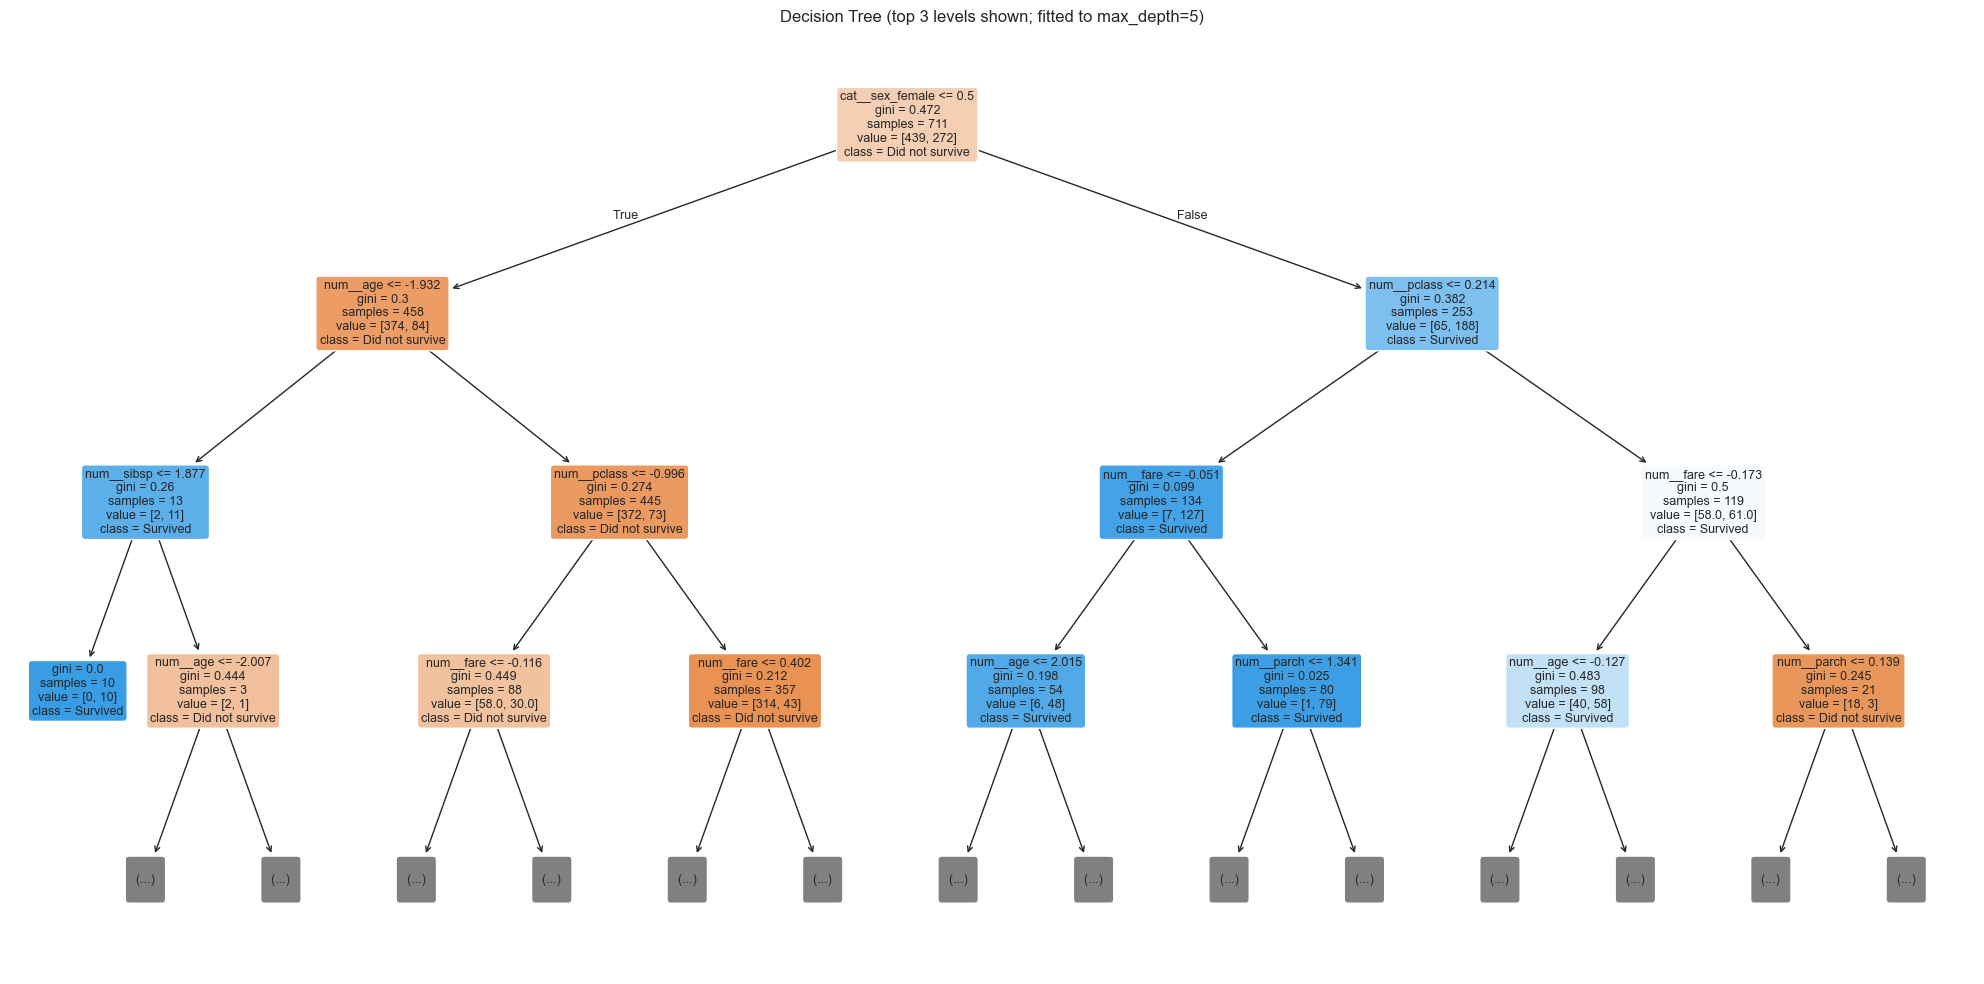

In [6]:
dt_pipe = pipelines["Decision Tree"]
feature_names = get_feature_names(dt_pipe.named_steps["preprocessor"])

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_pipe.named_steps["classifier"],
    feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3,  # only the top 3 levels are readable at this size; the fitted tree itself uses max_depth=5
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision Tree (top 3 levels shown; fitted to max_depth=5)")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/08_decision_tree.png", dpi=120)
plt.show()

In [7]:
# Full-depth version (all 5 levels) saved separately -- large, but nothing hidden
fig, ax = plt.subplots(figsize=(34, 14))
plot_tree(
    dt_pipe.named_steps["classifier"],
    feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax,
)
ax.set_title("Decision Tree (full depth=5)")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/08b_decision_tree_full.png", dpi=120)
plt.close(fig)  # not displayed inline (too large to read at notebook width); see saved PNG

## 4. Evaluate all three: confusion matrix, accuracy, precision, recall, F1, ROC/AUC

In [8]:
comparison_table = evaluate_all(pipelines, X_test, y_test)
comparison_table.round(4)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.8258,0.8136,0.7059,0.7559,0.8600
Decision Tree,0.7753,0.7333,0.6471,0.6875,0.8336
Random Forest,0.7921,0.7460,0.6912,0.7176,0.8359


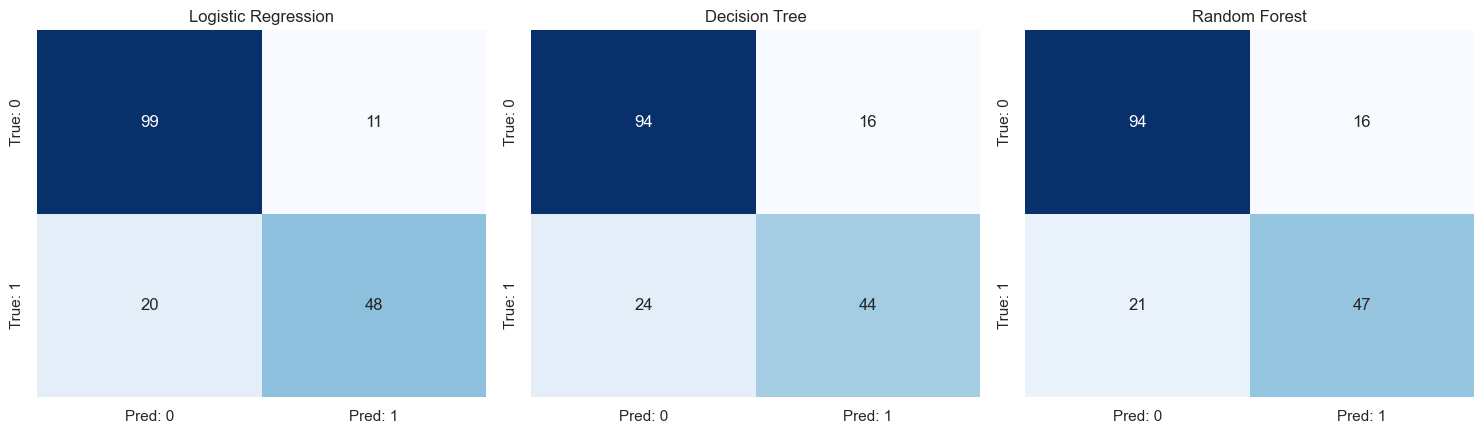

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, pipe) in zip(axes, pipelines.items()):
    m = evaluate_classifier(pipe, X_test, y_test)
    sns.heatmap(
        m["confusion_matrix"], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Pred: 0", "Pred: 1"], yticklabels=["True: 0", "True: 1"],
    )
    ax.set_title(name)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/09_confusion_matrices.png", dpi=120)
plt.show()

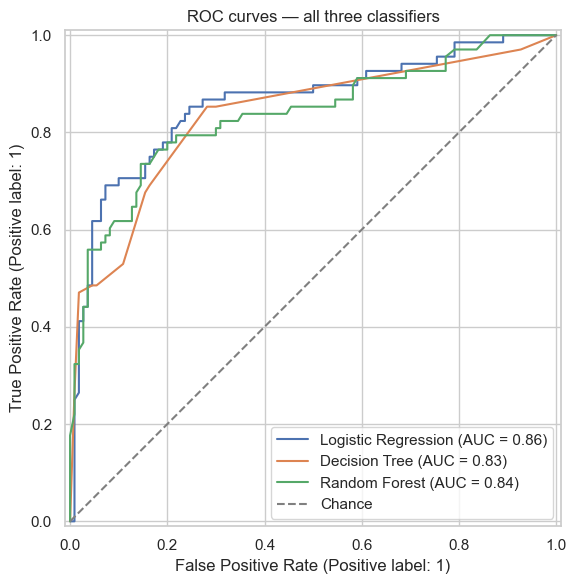

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, pipe in pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC curves — all three classifiers")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/10_roc_curves.png", dpi=120)
plt.show()

## 5. Imbalance handling comparison (Logistic Regression)

In [11]:
imbalance_results = compare_imbalance_strategies(X_train, y_train, X_test, y_test)
imbalance_results.round(4)

,precision,recall,f1
strategy,,,
baseline (no handling),0.8136,0.7059,0.7559
class_weight='balanced',0.7286,0.7500,0.7391
SMOTE (train fold only),0.7353,0.7353,0.7353


**Conclusion.** The baseline (no handling) wins on F1: precision 0.814,
recall 0.706, F1 0.756, versus F1 0.739 for `class_weight='balanced'`
(precision 0.729, recall 0.750) and F1 0.735 for SMOTE (precision 0.735,
recall 0.735). Both rebalancing strategies do what they are meant to —
recall rises by 3 to 4 points because the model is pushed to call more
borderline cases "survived" — but they give up 8 points of precision to get
it, which is a bad trade. That is expected here: the imbalance is mild
(~62/38, not extreme), so there is little minority-class signal being
ignored in the first place. These techniques would earn their keep on a much
more skewed target; on this one they mostly add noise.

## 6. Hyperparameter tuning: GridSearchCV over Random Forest

In [12]:
search = tune_random_forest(X_train, y_train, cv=5)
print("Best params:", search.best_params_)
print("Best CV F1:", search.best_score_)
oob = oob_score_of_best_estimator(search)
print("OOB score of best estimator:", oob)

tuned_rf_pipe = search.best_estimator_
tuned_metrics = evaluate_classifier(tuned_rf_pipe, X_test, y_test)
print("\nTuned Random Forest test metrics:")
print({k: v for k, v in tuned_metrics.items() if k not in ("confusion_matrix", "roc_curve")})

Best params: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 300}
Best CV F1: 0.7466022180496446
OOB score of best estimator: 0.8157524613220816

Tuned Random Forest test metrics:
{'accuracy': 0.8089887640449438, 'precision': 0.765625, 'recall': 0.7205882352941176, 'f1': 0.7424242424242424, 'roc_auc': 0.8364973262032085}


## 7. Regression side-task: predicting `fare`

In [13]:
reg_df = select_regression_columns(df)
Xr, yr = reg_df.drop(columns=["fare"]), reg_df["fare"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)

reg_pipe = build_regression_pipeline()
reg_pipe.fit(Xr_train, yr_train)
reg_metrics = evaluate_regression(reg_pipe, Xr_test, yr_test)
print({k: v for k, v in reg_metrics.items() if k not in ("y_pred", "residuals")})

{'mae': 21.123810542679145, 'rmse': 41.68427695854563, 'r2': 0.3487197762443649, 'adjusted_r2': 0.30972096045061426}


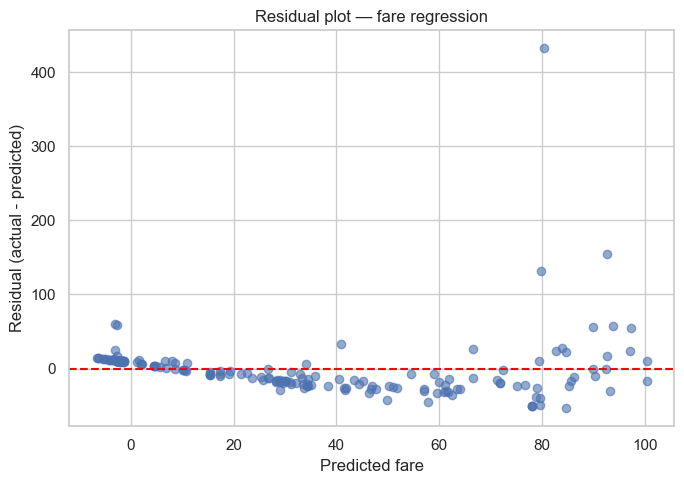

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(reg_metrics["y_pred"], reg_metrics["residuals"], alpha=0.6)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Predicted fare")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Residual plot — fare regression")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/11_regression_residuals.png", dpi=120)
plt.show()

**Heteroscedasticity check.** The residual spread visibly widens as
predicted fare increases — residuals cluster tightly near zero for cheap
predicted fares and fan out much further (both above and below zero) for
expensive predicted fares. That funnel/cone shape, rather than a uniform
band of scatter across the whole x-axis, is the classic signature of
**heteroscedasticity**: the model's error variance is not constant across
the range of predictions, so a single global error estimate understates
uncertainty for expensive tickets and overstates it for cheap ones.

## 8. Final model comparison and recommendation

In [15]:
classifier_block = comparison_table.copy()
classifier_block.loc["Random Forest (tuned)"] = {
    "accuracy": tuned_metrics["accuracy"],
    "precision": tuned_metrics["precision"],
    "recall": tuned_metrics["recall"],
    "f1": tuned_metrics["f1"],
    "roc_auc": tuned_metrics["roc_auc"],
}
print("=== Classification metrics (one scale: 0-1) ===")
display(classifier_block.round(4))

regression_block = pd.DataFrame(
    [{k: v for k, v in reg_metrics.items() if k in ("mae", "rmse", "r2", "adjusted_r2")}],
    index=["Linear Regression (fare)"],
)
print("\n=== Regression metrics (separate scale: MAE/RMSE in GBP, R2/Adj-R2 unitless 0-1) ===")
display(regression_block.round(4))

best_model_name = classifier_block["f1"].idxmax()
print(f"\nBest classifier by test F1: {best_model_name}")

=== Classification metrics (one scale: 0-1) ===


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.8258,0.8136,0.7059,0.7559,0.8600
Decision Tree,0.7753,0.7333,0.6471,0.6875,0.8336
Random Forest,0.7921,0.7460,0.6912,0.7176,0.8359
Random Forest (tuned),0.8090,0.7656,0.7206,0.7424,0.8365



=== Regression metrics (separate scale: MAE/RMSE in GBP, R2/Adj-R2 unitless 0-1) ===


,mae,rmse,r2,adjusted_r2
Linear Regression (fare),21.1238,41.6843,0.3487,0.3097



Best classifier by test F1: Logistic Regression


**Recommendation: deploy Logistic Regression.** It has the best F1 (0.756),
accuracy (0.826) and ROC-AUC (0.860) of the four classifier variants; the
untuned Random Forest reaches F1 0.718 and AUC 0.836, the Decision Tree
F1 0.688 and AUC 0.834, and the `GridSearchCV`-tuned Random Forest
(300 trees, `max_features='sqrt'`, unlimited depth) closes only part of the
gap at F1 0.742 and AUC 0.836. F1 is the deciding metric rather than raw
accuracy because `survived` is imbalanced (~62/38), so accuracy alone
rewards a model that leans toward the majority class. That a simple linear
model beats a tuned ensemble suggests these 7 features are already captured
by a near-linear boundary, so the ensemble's extra complexity buys nothing.
The `fare` regression is a different kind of problem and is deliberately
reported separately: its R2 of 0.349 (Adjusted R2 0.310, MAE 21.12, RMSE
41.68) is far below any classifier's accuracy, but a continuous, heavy-tailed
value predicted from a handful of passenger attributes is inherently
noisier than a binary label, and the two sets of metrics are not on a
comparable scale.

## 9. Persist the best full pipeline (preprocessing + estimator)

In [16]:
candidate_pipelines = dict(pipelines)
candidate_pipelines["Random Forest (tuned)"] = tuned_rf_pipe
best_pipeline = candidate_pipelines[best_model_name]

model_path = "models/best_titanic_classifier.joblib"
save_pipeline(best_pipeline, model_path)
print(f"Saved '{best_model_name}' full pipeline to {model_path}")

Saved 'Logistic Regression' full pipeline to models/best_titanic_classifier.joblib


In [17]:
reloaded = load_pipeline(model_path)

raw_new_passengers = pd.DataFrame(
    [
        {"pclass": 1, "sex": "female", "age": 29, "sibsp": 0, "parch": 0, "fare": 100.0, "embarked": "S"},
        {"pclass": 3, "sex": "male", "age": None, "sibsp": 1, "parch": 0, "fare": 7.25, "embarked": None},
    ]
)
predictions = predict_on_raw(reloaded, raw_new_passengers)
print("Predictions on raw (unpreprocessed, includes missing values) new data:", predictions)
assert reloaded.predict(X_test).tolist() == best_pipeline.predict(X_test).tolist()
print("Reloaded pipeline predictions on X_test match the original in-memory pipeline exactly.")

Predictions on raw (unpreprocessed, includes missing values) new data: [1 0]
Reloaded pipeline predictions on X_test match the original in-memory pipeline exactly.
